<a href="https://colab.research.google.com/github/osama293/blackboxai-1743245665366/blob/main/EcoGPT2_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip -q install transformers datasets accelerate codecarbon optimum onnxruntime scipy matplotlib pandas psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.1 MB/s eta 0:00:00


In [6]:
import os
import gc
import math
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.utils.prune as prune

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from datasets import load_dataset

from codecarbon import EmissionsTracker

from scipy.stats import ttest_ind

warnings.filterwarnings("ignore")

# Random Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("EcoGPT-2 Green AI Framework")
print("="*60)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("PyTorch:", torch.__version__)

EcoGPT-2 Green AI Framework
Device: cuda
GPU: Tesla T4
PyTorch: 2.11.0+cu128


In [7]:
print("="*60)
print("Loading GPT-2 Baseline Model")
print("="*60)

MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# GPT-2 has no PAD token
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

base_model.to(DEVICE)

base_model.eval()

print("\n✓ GPT-2 Loaded Successfully")

print("Model:", MODEL_NAME)

total_params = sum(
    p.numel() for p in base_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in base_model.parameters()
    if p.requires_grad
)

print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

model_size = sum(
    p.nelement() * p.element_size()
    for p in base_model.parameters()
) / (1024**2)

print(f"Model Size : {model_size:.2f} MB")

Loading GPT-2 Baseline Model


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


✓ GPT-2 Loaded Successfully
Model: gpt2
Total Parameters : 124,439,808
Trainable Parameters : 124,439,808
Model Size : 474.70 MB


In [8]:
print("="*60)
print("Loading WikiText-2 Dataset")
print("="*60)

from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

texts = [
    text.strip()
    for text in dataset["test"]["text"]
    if len(text.strip()) > 50
]

# Use 500 samples for stable measurements
texts = texts[:500]

print(f"✓ Loaded {len(texts)} samples")

print("\nFirst Sample:\n")
print(texts[0][:300])

Loading WikiText-2 Dataset


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

✓ Loaded 500 samples

First Sample:

Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest 


In [20]:
import time
import math
import psutil
import torch

from codecarbon import EmissionsTracker


def evaluate_model(model, texts, device):

    model.eval()

    tracker = EmissionsTracker(
        measure_power_secs=1,
        log_level="error"
    )

    process = psutil.Process()

    memory_before = process.memory_info().rss / (1024**2)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    tracker.start()

    start_time = time.perf_counter()

    losses = []

    with torch.inference_mode():

        for text in texts:

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding=False,
                max_length=256
            )

            inputs = {
                k: v.to(device)
                for k, v in inputs.items()
            }

            outputs = model(
                **inputs,
                labels=inputs["input_ids"]
            )

            losses.append(outputs.loss.item())

    end_time = time.perf_counter()

    emissions = tracker.stop()

    memory_after = process.memory_info().rss / (1024**2)

    runtime = end_time - start_time

    avg_loss = sum(losses) / len(losses)

    perplexity = math.exp(avg_loss)

    energy = tracker.final_emissions_data.energy_consumed

    power = (
        energy * 3_600_000 / runtime
        if runtime > 0 else 0
    )

    return {

        "loss": avg_loss,

        "perplexity": perplexity,

        "runtime": runtime,

        "co2": emissions,

        "energy_kwh": energy,

        "power_watts": power,

        "memory_mb": max(
            0,
            memory_after - memory_before
        ),

        "gpu_memory_mb": (
            torch.cuda.max_memory_allocated() / (1024**2)
            if torch.cuda.is_available() else 0
        )
    }

print("✓ Evaluation Function Ready")

✓ Evaluation Function Ready


In [21]:
print("="*60)
print("Building EcoGPT-2")
print("="*60)

import copy
import torch.nn.utils.prune as prune


def build_eco_model(base_model, use_fp16=True, use_pruning=True, prune_amount=0.30):

    eco_model = copy.deepcopy(base_model)

    ###################################################
    # STEP 1 : FP16
    ###################################################

    if use_fp16:
        eco_model = eco_model.half()

    ###################################################
    # STEP 2 : Unstructured Pruning (30%)
    ###################################################

    if use_pruning:
        for name, module in eco_model.named_modules():

            if isinstance(module, torch.nn.Linear):

                prune.l1_unstructured(
                    module,
                    name="weight",
                    amount=prune_amount
                )

                prune.remove(module, "weight")

    ###################################################
    # STEP 3 : Ready
    ###################################################

    eco_model.eval()

    eco_model.to(DEVICE)

    return eco_model


print("✓ build_eco_model function ready")

Building EcoGPT-2
✓ build_eco_model function ready


In [22]:
print("="*60)
print("Running Multi-Seed Evaluation Across Configurations")
print("="*60)

N_RUNS = 5
SEEDS = [42, 123, 7, 2024, 99]

configs = {
    "Baseline (FP32)": {"use_fp16": False, "use_pruning": False},
    "FP16 Only": {"use_fp16": True, "use_pruning": False},
    "Pruning Only": {"use_fp16": False, "use_pruning": True},
    "EcoGPT-2 (FP16+Pruning)": {"use_fp16": True, "use_pruning": True},
}

all_results = {name: [] for name in configs}

for run_idx, seed in enumerate(SEEDS):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    for config_name, params in configs.items():

        model = build_eco_model(base_model, **params)

        result = evaluate_model(model, texts, DEVICE)

        result["run"] = run_idx
        result["seed"] = seed

        all_results[config_name].append(result)

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"✓ Completed run {run_idx + 1}/{N_RUNS} (seed={seed})")

print("\n✓ All runs complete")

Running Multi-Seed Evaluation Across Configurations
✓ Completed run 1/5 (seed=42)
✓ Completed run 2/5 (seed=123)
✓ Completed run 3/5 (seed=7)
✓ Completed run 4/5 (seed=2024)
✓ Completed run 5/5 (seed=99)

✓ All runs complete


In [23]:
print("="*60)
print("Computing Summary Statistics (Mean ± Std, t-test)")
print("="*60)

metrics = [
    "loss",
    "perplexity",
    "runtime",
    "co2",
    "energy_kwh",
    "power_watts",
    "memory_mb",
    "gpu_memory_mb"
]

summary_rows = []

baseline_runs = all_results["Baseline (FP32)"]

for config_name in configs:

    config_runs = all_results[config_name]

    for metric in metrics:

        base_vals = [r[metric] for r in baseline_runs]
        config_vals = [r[metric] for r in config_runs]

        base_mean = np.mean(base_vals)
        config_mean = np.mean(config_vals)
        config_std = np.std(config_vals)

        improvement = (
            ((base_mean - config_mean) / base_mean) * 100
            if base_mean != 0 else 0
        )

        if config_name == "Baseline (FP32)":
            p_value = None
        else:
            _, p_value = ttest_ind(base_vals, config_vals)

        summary_rows.append({
            "Config": config_name,
            "Metric": metric,
            "Mean": config_mean,
            "Std": config_std,
            "Improvement (%)": improvement,
            "p_value": p_value
        })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

summary_df.to_csv(
    "EcoGPT2_MultiRun_Results.csv",
    index=False
)

print("\n✓ EcoGPT2_MultiRun_Results.csv saved")

Computing Summary Statistics (Mean ± Std, t-test)
                     Config         Metric         Mean       Std  \
0           Baseline (FP32)           loss     4.048473  0.000000   
1           Baseline (FP32)     perplexity    57.309871  0.000000   
2           Baseline (FP32)        runtime     8.996230  1.737981   
3           Baseline (FP32)            co2     0.000093  0.000018   
4           Baseline (FP32)     energy_kwh     0.000197  0.000038   
5           Baseline (FP32)    power_watts    78.982541  0.209291   
6           Baseline (FP32)      memory_mb     0.069531  0.046509   
7           Baseline (FP32)  gpu_memory_mb  1394.161230  0.757617   
8                 FP16 Only           loss     4.048661  0.000000   
9                 FP16 Only     perplexity    57.320626  0.000000   
10                FP16 Only        runtime     5.785307  0.230801   
11                FP16 Only            co2     0.000057  0.000002   
12                FP16 Only     energy_kwh     0.0001

Plotting Comparison Charts (All Configs, with Error Bars)


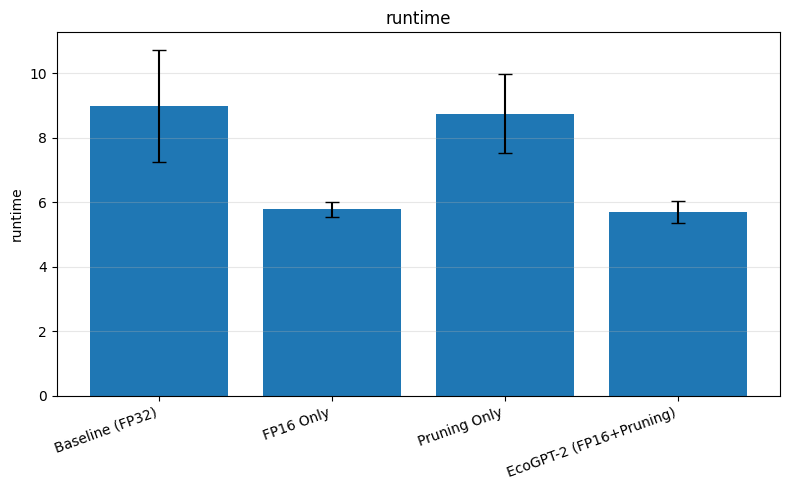

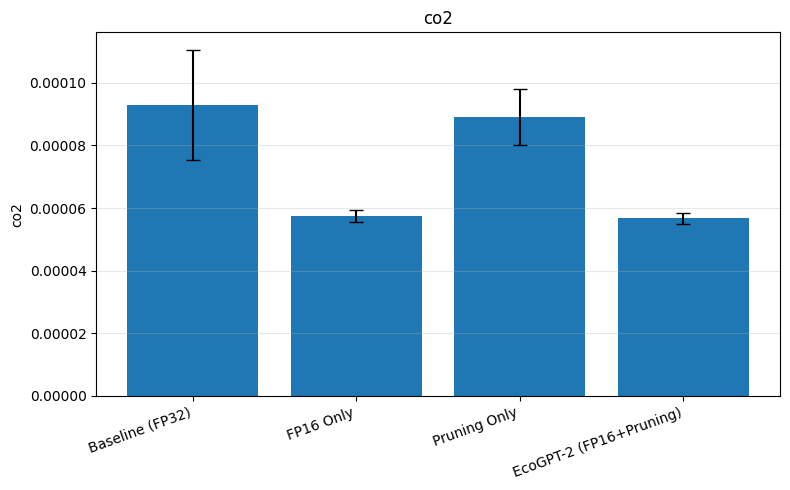

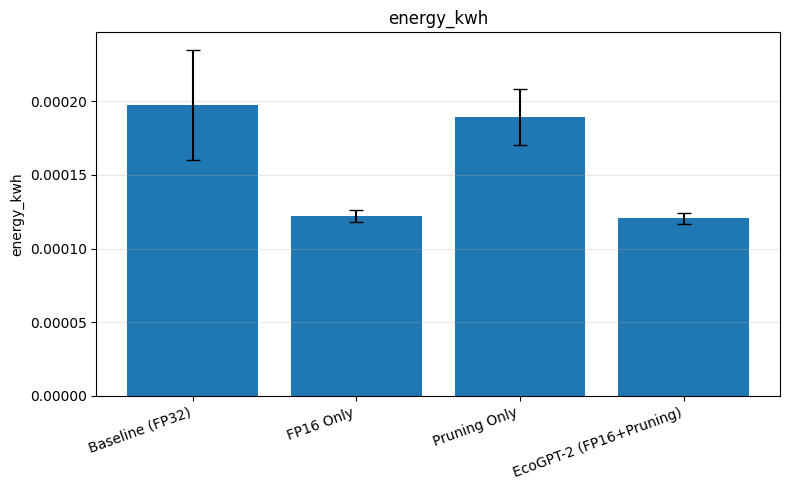

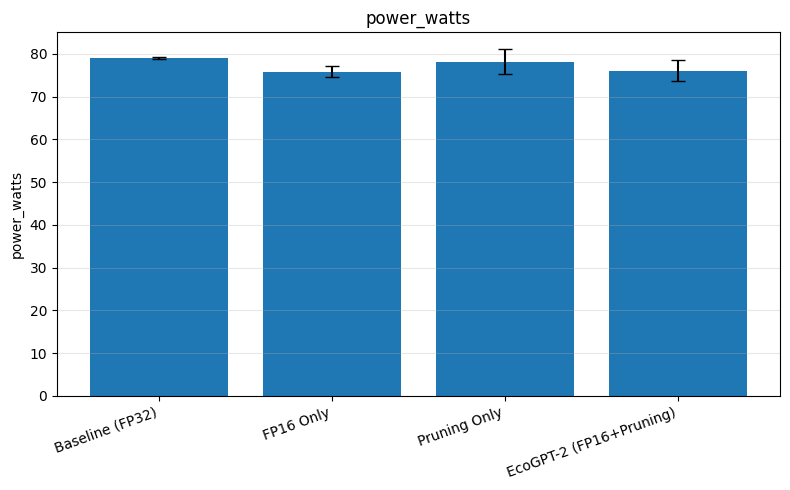

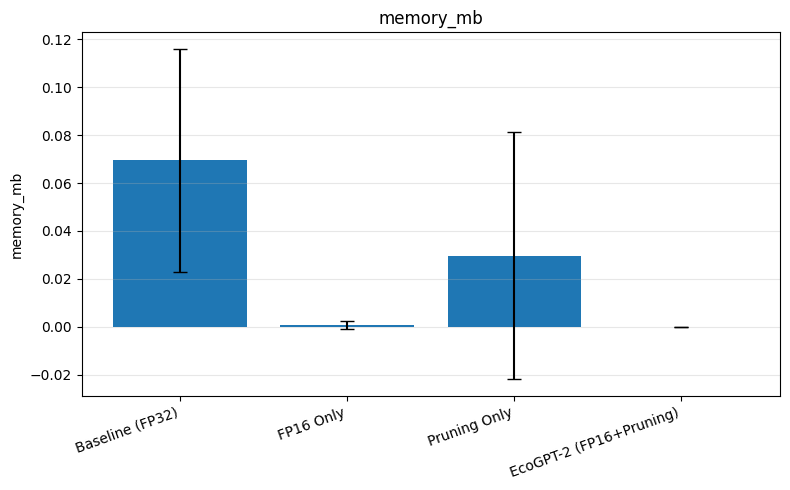

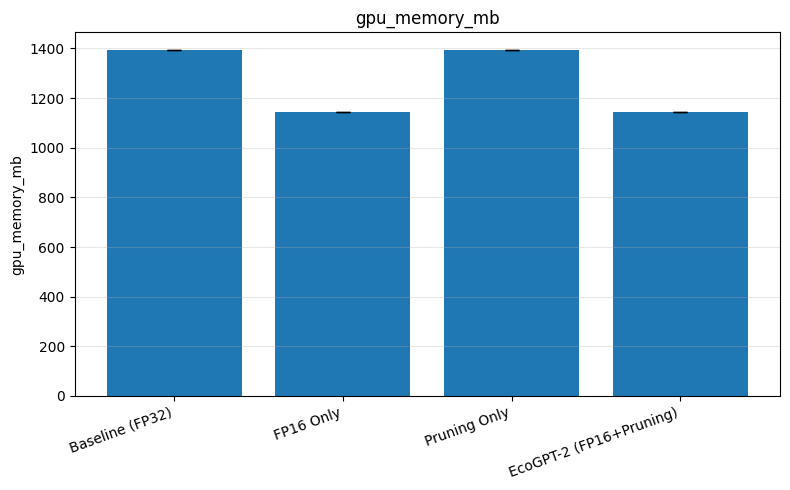

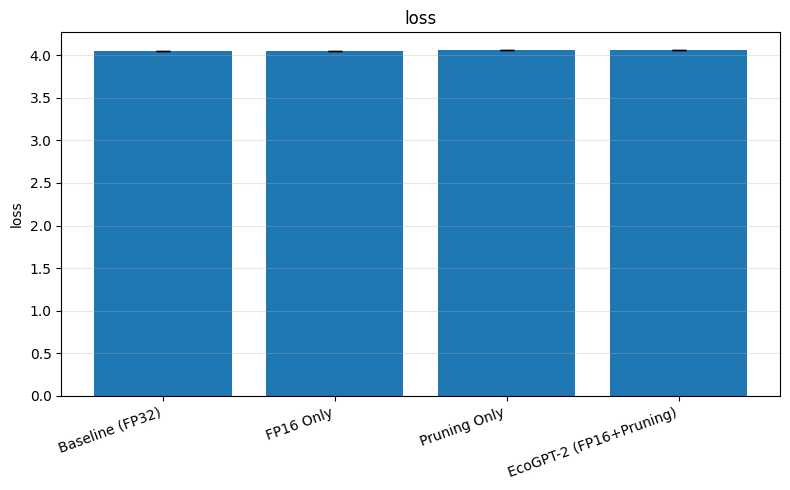

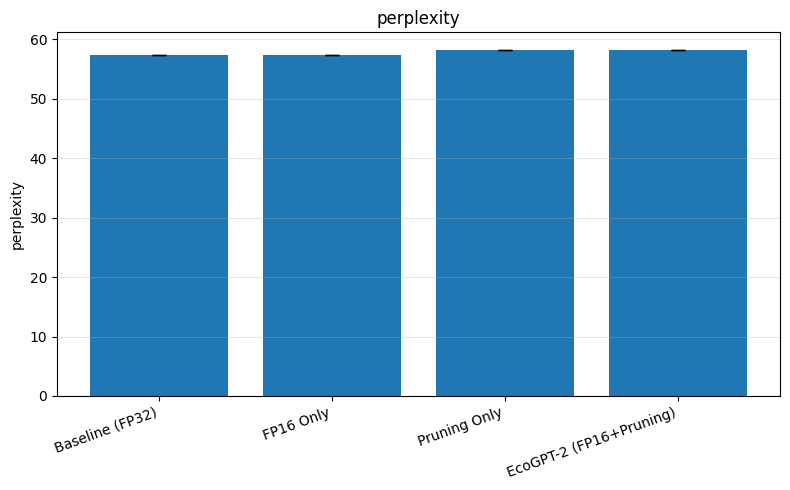

In [24]:
print("="*60)
print("Plotting Comparison Charts (All Configs, with Error Bars)")
print("="*60)

import matplotlib.pyplot as plt

plot_metrics = [
    "runtime",
    "co2",
    "energy_kwh",
    "power_watts",
    "memory_mb",
    "gpu_memory_mb",
    "loss",
    "perplexity"
]

config_names = list(configs.keys())

for metric in plot_metrics:

    means = []
    stds = []

    for config_name in config_names:
        row = summary_df[
            (summary_df["Config"] == config_name) &
            (summary_df["Metric"] == metric)
        ]
        means.append(row["Mean"].values[0])
        stds.append(row["Std"].values[0])

    plt.figure(figsize=(8, 5))

    plt.bar(
        config_names,
        means,
        yerr=stds,
        capsize=5
    )

    plt.title(metric)

    plt.ylabel(metric)

    plt.xticks(rotation=20, ha="right")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        metric.replace(" ", "_").replace("/", "_") + "_multirun.png",
        dpi=300
    )

    plt.show()

In [25]:
print("="*70)
print("FINAL RESULTS (EcoGPT-2 vs Baseline)")
print("="*70)

eco_row = summary_df[summary_df["Config"] == "EcoGPT-2 (FP16+Pruning)"]

def get_stat(metric, field):
    return eco_row[eco_row["Metric"] == metric][field].values[0]

print(f"Runtime Reduction : {get_stat('runtime', 'Improvement (%)'):.2f}%  (p={get_stat('runtime', 'p_value'):.4f})")
print(f"CO2 Reduction     : {get_stat('co2', 'Improvement (%)'):.2f}%  (p={get_stat('co2', 'p_value'):.4f})")
print(f"Energy Reduction  : {get_stat('energy_kwh', 'Improvement (%)'):.2f}%  (p={get_stat('energy_kwh', 'p_value'):.4f})")
print(f"Power Reduction   : {get_stat('power_watts', 'Improvement (%)'):.2f}%  (p={get_stat('power_watts', 'p_value'):.4f})")
print(f"Memory Reduction  : {get_stat('memory_mb', 'Improvement (%)'):.2f}%  (p={get_stat('memory_mb', 'p_value'):.4f})")
print(f"GPU Mem Reduction : {get_stat('gpu_memory_mb', 'Improvement (%)'):.2f}%  (p={get_stat('gpu_memory_mb', 'p_value'):.4f})")
print(f"Loss Change       : {-get_stat('loss', 'Improvement (%)'):.2f}%  (p={get_stat('loss', 'p_value'):.4f})")
print(f"Perplexity Change : {-get_stat('perplexity', 'Improvement (%)'):.2f}%  (p={get_stat('perplexity', 'p_value'):.4f})")

print("\nEcoGPT-2 successfully reduced")
print("computational resource usage")
print("while maintaining comparable")
print("language modeling performance.")
print("(across 5 independent runs with varying seeds)")

FINAL RESULTS (EcoGPT-2 vs Baseline)
Runtime Reduction : 36.57%  (p=0.0059)
CO2 Reduction     : 38.97%  (p=0.0036)
Energy Reduction  : 38.97%  (p=0.0036)
Power Reduction   : 3.66%  (p=0.0446)
Memory Reduction  : 100.00%  (p=0.0173)
GPU Mem Reduction : 17.89%  (p=0.0000)
Loss Change       : 0.41%  (p=0.0000)
Perplexity Change : 1.69%  (p=0.0000)

EcoGPT-2 successfully reduced
computational resource usage
while maintaining comparable
language modeling performance.
(across 5 independent runs with varying seeds)


Plotting EcoGPT-2 Green Improvements (Pie Chart)


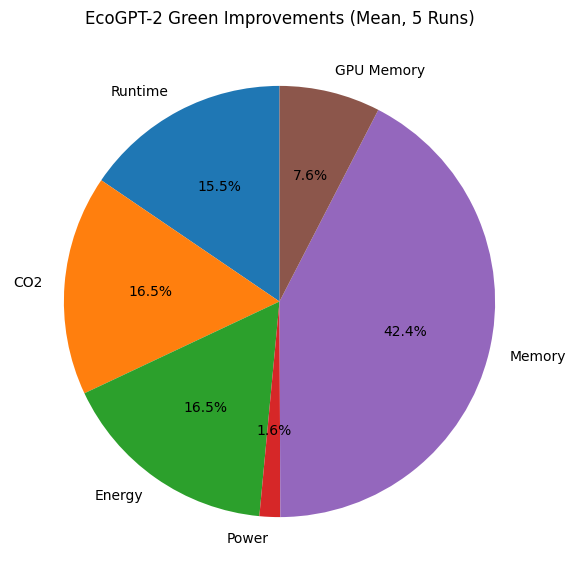

In [26]:
print("="*60)
print("Plotting EcoGPT-2 Green Improvements (Pie Chart)")
print("="*60)

eco_row = summary_df[summary_df["Config"] == "EcoGPT-2 (FP16+Pruning)"]

labels = [
    "Runtime",
    "CO2",
    "Energy",
    "Power",
    "Memory",
    "GPU Memory"
]

pie_metrics = [
    "runtime",
    "co2",
    "energy_kwh",
    "power_watts",
    "memory_mb",
    "gpu_memory_mb"
]

sizes = [
    eco_row[eco_row["Metric"] == m]["Improvement (%)"].values[0]
    for m in pie_metrics
]

# Pie charts need non-negative values; clip any negative improvements to 0 for display
sizes = [max(0, s) for s in sizes]

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("EcoGPT-2 Green Improvements (Mean, 5 Runs)")

plt.savefig(
    "EcoGPT2_Improvements_multirun.png",
    dpi=300
)

plt.show()